In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [4]:
# Reset!
os.chdir('/home/jen55/palmer_scratch/DRAGON_CNN_NEW/DRAGON_CNN/modules/')

In [5]:
loss_csv = pd.read_csv("accuracy.csv")
accuracy_csv = pd.read_csv("loss.csv")

loss = loss_csv["usual-energy-1 - devel_loss"]
accuracy = accuracy_csv["usual-energy-1 - devel_accuracy"]

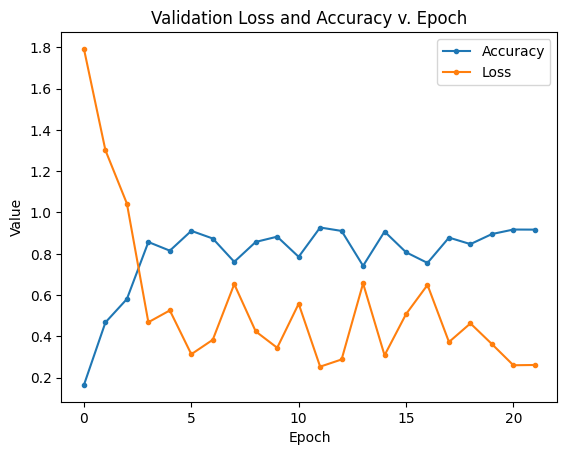

In [6]:
plt.title("Validation Loss and Accuracy v. Epoch")
x = np.arange(0, len(accuracy), 1)
plt.plot(x, accuracy, label="Accuracy", marker=".")
plt.plot(x, loss, label="Loss", marker=".")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.show()

In [7]:
# Changing to W&B directory
os.chdir('/home/jen55/palmer_scratch/DRAGON_CNN_NEW/DRAGON_CNN/wandb')

In [27]:
def calculate_accuracies(df):
    num_classes = df["Actual"].nunique()
    
    classPreds = [0] * num_classes  # The total number of galaxies predicted as each class.
    classActual = [0] * num_classes  # The actual number of galaxies correctly predicted.
    classTotal = [0] * num_classes  # The total number of actual galaxies in each class.

    for _, row in df.iterrows():
        classTotal[row["Actual"]] += row["nPredictions"]
        classPreds[row["Predicted"]] += row["nPredictions"]
        if row["Actual"] == row["Predicted"]:
            classActual[row["Actual"]] += row["nPredictions"]

    accuracies = [0] * num_classes
    for i in range(num_classes):
        if classTotal[i] > 0:
            accuracies[i] = classActual[i] / classTotal[i]
        else:
            accuracies[i] = 0

    return accuracies

In [50]:
# Changing to desired run.
run_name = 'sjxbss6g'
for folder in os.listdir(os.getcwd()):
    if Path(folder).is_dir() and run_name in folder:
        os.chdir(folder + '/files/media/table')
        break

class_accuracies = dict()
for fl in Path('.').glob('*.json'):
    file_str = fl.as_posix()
    if 'devel' in file_str:
        file_num = file_str.split('_')[4]
        with open(fl, "r") as file:
            jsonString = file.read()
            df = pd.read_json(jsonString, orient='split')
            class_accuracies[int(file_num)] = calculate_accuracies(df)

class_accuracies = dict(sorted(class_accuracies.items()))
class_accuracies = list(class_accuracies.values())
per_time = list(zip(*class_accuracies))
print(per_time)

[(0.0, 0.6486454513190584, 0.4484798296462794, 0.9567017626878032, 0.9626168224299065, 0.6876848456169408, 0.9576481722465396, 0.9570566662723293, 0.9523246184786467, 0.9363539571749675, 0.8130841121495327, 0.956465160298119, 0.9522063172838046, 0.9539808352064356, 0.782207500295753, 0.9517331125044363, 0.9571749674671715, 0.9623802200402224, 0.9517331125044363, 0.9593043889743287, 0.9273630663669703, 0.9260617532237075), (0.0, 0.8171848638226079, 0.7431911303928658, 0.9621595565196432, 0.9713183899734876, 0.7806700409737286, 0.9768618944323934, 0.9548083875632682, 0.9843335743552664, 0.9621595565196432, 0.9416726922149916, 0.9871053265847192, 0.9498674379368522, 0.8976861894432393, 0.9818028440588094, 0.9927693420101229, 0.972764521571463, 0.977825982164377, 0.977705471197879, 0.9904796336466618, 0.9397445167510243, 0.9391419619185346), (1.0, 0.6526600753295668, 0.4945856873822976, 0.8625235404896422, 0.8559322033898306, 0.4066619585687382, 0.8621704331450094, 0.876647834274953, 0.859

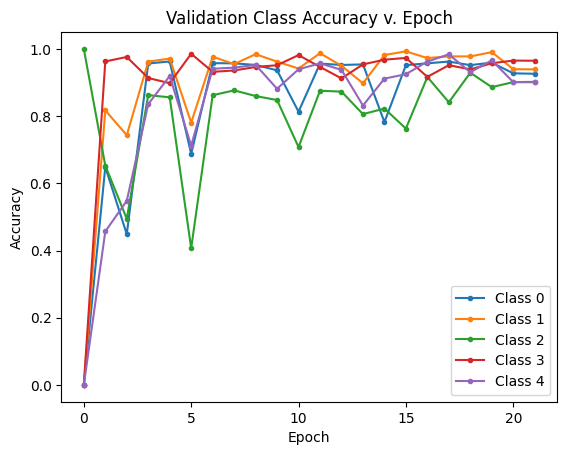

In [52]:
plt.title("Validation Class Accuracy v. Epoch")
x = np.arange(0, len(class_accuracies), 1)
for i in range(len(per_time)):
    plt.plot(x, per_time[i], label=f"Class {i}", marker=".")
    
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()